In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


This notebook calculates the relatives ocntribution of each high level food group in SHeS 2021 to nutrient intake, environmental impact and cost

In [ ]:
%cd /content/drive/MyDrive/mSHIFT_SHeS/code_ocean/

/content/drive/MyDrive/mSHIFT_SHeS/code_ocean


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
import sys
import os

data_path = Path("data")
results_path = Path("results")

In [ ]:
plt.rcParams["font.family"] = 'serif'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.formatter.use_mathtext"] = True

In [ ]:
sys.path.append(str(Path().resolve() / 'code/notebooks/notebook_code'))

In [ ]:
from food_group_contributions import item_contribution_env_impact, item_contribution_nutrients, item_contribution_nutrients_daily_average, stacked_bar_plot

In [ ]:
diet_data = pd.read_parquet(data_path / 'diet_data.parquet')
df_baseline = pd.read_parquet(data_path / 'df_baseline.parquet')

In [ ]:
nutrients = np.loadtxt(data_path / 'indicator_lists/nutrients.txt', dtype=str).tolist()
env_columns = np.loadtxt(data_path / 'indicator_lists/env_columns.txt', dtype=str).tolist()
mean_env_columns = np.loadtxt(data_path / 'indicator_lists/mean_env_columns.txt', dtype=str).tolist()
error_columns = np.loadtxt(data_path / 'indicator_lists/error_columns.txt', dtype=str).tolist()

In [ ]:
with open(data_path / 'mappings/nutrient_label_dict.json', 'r') as f:
    nutrient_label_dict = json.load(f)

In [ ]:
df_impacts = pd.read_parquet(data_path / 'df_impacts_per_100g_1902.parquet')

In [ ]:
price_cols = []
for col in df_impacts.columns:
  if 'price' in col.lower():
    price_cols.append(col)

## Evaluate food group contributions to nutrient intake

In [ ]:
column_grouping = "FoodCategory"
main_category_sums = pd.DataFrame(index=diet_data[column_grouping].unique(), columns = nutrients + mean_env_columns)
main_category_sums.loc[:, :] = 0

# Environmental impact contribution
main_category_sums = main_category_sums.apply(lambda row: item_contribution_env_impact(row,
                                                                                       column_grouping=column_grouping,
                                                                                       diet_data = diet_data,
                                                                                       columns=mean_env_columns),
                                               axis=1)

# Nutrient contribution
main_category_sums = main_category_sums.apply(lambda row: item_contribution_nutrients(row,
                                                                                      column_grouping=column_grouping,
                                                                                      diet_data=diet_data,
                                                                                      df_baseline=df_baseline,
                                                                                      columns = nutrients),
                                              axis=1)


In [ ]:
main_category_sums.to_parquet(data_path / 'main_category_sums.parquet')

In [ ]:
main_category_sums = pd.read_parquet(data_path / 'main_category_sums.parquet')

In [ ]:
import importlib

In [ ]:
import food_group_contributions

In [ ]:
importlib.reload(food_group_contributions)
from food_group_contributions import stacked_bar_plot


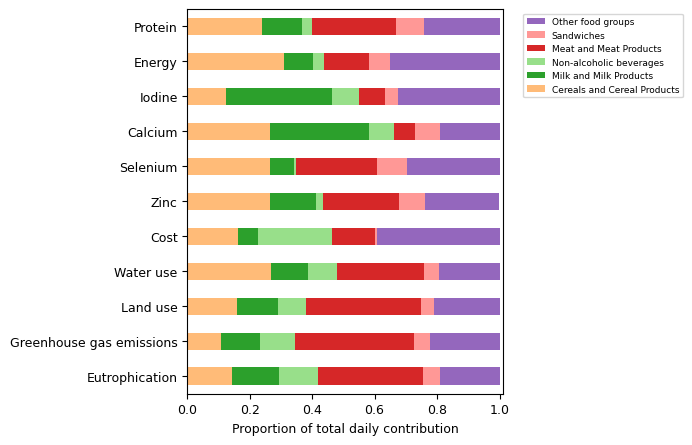

In [ ]:
plot_name_main = 'Figure1'
columns_to_group = ['Fish and Fish Dishes', 'Eggs and Egg Dishes', 'Vegetables, potatoes', 'Fat Spreads', 'Savoury Snacks', 'Nuts and Seeds', 'Misc', 'Fruit', 'Alcoholic beverages', 'Sugar, Preserves and Confectionery']

env_indicators_selected = [ 'median_Eut',
'median_GHG',
 'median_Land',
 'median_WaterUse',
'median_price_sim']

nutrients_selected = [

 'Zincmg',
  'Selenium',
  'Calciummg',
 'Iodine',
 'Energykcal',
 'Proteing',

              ]

save_path = Path(results_path / "Plots/food_group_contributions/")
if not os.path.exists(save_path):
    os.makedirs(save_path, exist_ok=True)

stacked_bar_plot(env_columns=env_indicators_selected,
                 nutrients=nutrients_selected,
                 main_category_sums=main_category_sums,
                 plot_name=plot_name_main,
                 nutrient_label_dict=nutrient_label_dict,
                 save_fig=True,
                 save_path=save_path,
                 columns_to_group=columns_to_group)

In [ ]:
percent_contributions = main_category_sums.div(main_category_sums.sum(axis=0), axis=1)

In [ ]:
main_category_sums = pd.read_parquet(data_path / 'main_category_sums.parquet')

In [ ]:
main_category_sums.loc[:, mean_env_columns].sum(axis=0)

,0
mean_GHG,2.343618e+07
mean_Land,3.769842e+07
mean_WatScar,6.415309e+10
mean_Eut,1.215167e+08
mean_Acidification,1.455125e+08
mean_WaterUse,2.634691e+09
mean_Biodiversity,1.211025e+09
median_GHG,1.944620e+07
median_Land,2.595355e+07
median_WatScar,4.512402e+10


Produce the results table of percent contribution to imapct and nutrient intake

In [ ]:
main_category_sums.loc[:, mean_env_columns] = main_category_sums.loc[:, mean_env_columns].div(main_category_sums.loc[:, mean_env_columns].sum(axis=0), axis=1)

rename_dict = {'median_Eut': 'Eutrophication',
               'median_GHG': "Greenhouse gas emissions",
               'median_Land': "Land use",
               'median_WaterUse': 'Water use',
               'median_price_sim': 'Cost'}

main_category_sums[mean_env_columns].rename(columns=rename_dict, inplace=True)

/tmp/ipython-input-49548759.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_category_sums[mean_env_columns].rename(columns=rename_dict, inplace=True)


In [ ]:
main_category_file = main_category_sums.copy()
main_category_file.drop(labels=['Toddler foods', 'Artificial sweeteners'], axis=0, inplace=True)
main_category_file = np.round(main_category_file*100, 1)

In [ ]:
indicators_to_drop =  [
    "EnergykJ",
    'Beefg',
 'Lambg',
 'Porkg',
 'ProcessedRedMeatg',
 'OtherRedMeatg',
 'Burgersg',
 'Sausagesg',
 'Offalg',
 'Poultryg',
 'GameBirdsg',
 'ProcessedPoultryg',
 'WhiteFishg',
 'OilyFishg',
 'CannedTunag',
 'Shellfishg',
 'Fruitg',
 'DriedFruitg',
 'FruitJuiceg',
 'SmoothieFruitg',
 'Tomatoesg',
 'TomatoPureeg',
 'Brassicaceaeg',
 'YellowRedGreeng',
 'Beansg',
 'Nutsg',
 'OtherVegg',
 'Milk_Skimmed',
 'Milk_SemiSkimmed',
 'Milk_Whole',
 'Cheese_Skimmed',
 'Cheese_SemiSkimmed',
 'Cheese_Whole',
 'Yogurt_Skimmed',
 'Yogurt_SemiSkimmed',
 'Yogurt_Whole',
 'Cream_SemiSkimmed',
 'Cream_Whole',
 'Butter',
 'mean_GHG',
 'mean_Land',
 'mean_WatScar',
 'mean_Eut',
 'mean_Acidification',
 'mean_WaterUse',
 'mean_Biodiversity',
    'median_WatScar',
    'median_Biodiversity',
    'median_Acidification',
                       'TotalGrams'

                       ]

In [ ]:
main_category_file.drop(columns = indicators_to_drop, inplace=True)

In [ ]:
key_nutrients = [nutr for nutr in nutrients if nutr not in indicators_to_drop]

In [ ]:
env_rename_dict = {'median_Eut': 'Eutrophication',
               'median_GHG': "Greenhouse gas emissions",
               'median_Land': "Land use",
               'median_WaterUse': 'Water use',
               'median_price_sim': 'Cost'}

nutrient_rename_dict = {nutr: f"{nutrient_label_dict[nutr]['title']}" for nutr in key_nutrients}
main_category_file.rename(columns=nutrient_rename_dict, inplace=True)
main_category_file.rename(columns=env_rename_dict, inplace=True)

In [ ]:
main_category_file

,Energy,Protein,Fat,Carbohydrate,Sodium,Potassium,Calcium,Magnesium,Phosphorus,Iron,...,Saturated fatty acids,Cis monounsaturated fatty acids,n-6 fatty acids,n-3 fatty acids,Trans fatty acids,Greenhouse gas emissions,Land use,Eutrophication,Water use,Cost
"Vegetables, potatoes",8.6,6.9,8.3,10.4,6.7,17.7,6.5,11.9,7.9,11.5,...,5.2,8.7,14.2,13.7,5.0,3.4,6.6,5.2,4.6,8.9
Cereals and Cereal Products,31.0,23.7,22.0,42.6,26.6,15.2,26.4,26.0,24.4,38.6,...,21.7,20.5,28.2,22.1,17.3,10.7,15.9,14.2,26.8,16.2
Fat Spreads,2.4,0.0,6.9,0.0,1.4,0.1,0.1,0.0,0.1,0.0,...,8.8,6.4,4.1,6.4,10.5,0.3,0.4,0.4,0.2,0.5
Milk and Milk Products,9.2,13.1,12.4,6.1,9.0,11.2,31.9,9.6,18.2,2.1,...,19.4,8.6,3.1,3.8,25.6,12.6,13.1,15.0,11.9,6.3
Non-alcoholic beverages,3.6,2.9,0.9,5.7,1.9,14.8,7.8,12.7,7.7,3.6,...,1.4,0.6,0.5,0.4,2.1,11.4,9.0,12.5,9.4,23.6
Fruit,3.9,1.5,1.1,7.0,0.4,7.6,1.6,5.4,1.6,3.2,...,0.7,1.2,1.5,2.6,0.0,4.0,2.1,2.2,2.8,4.5
Meat and Meat Products,14.3,27.2,18.8,6.6,19.7,13.2,6.6,11.6,17.4,15.8,...,18.0,20.9,18.1,17.8,20.7,37.9,36.8,33.9,27.8,13.8
Nuts and Seeds,1.3,1.1,2.6,0.3,0.4,1.0,0.5,2.3,1.3,1.3,...,1.4,3.1,4.4,2.7,0.3,0.7,1.1,0.4,1.0,0.6
Misc,3.3,3.1,4.1,2.9,10.9,4.0,3.0,3.1,2.7,4.5,...,3.2,4.4,5.3,6.3,3.0,1.8,2.8,2.4,1.9,5.0
"Sugar, Preserves and Confectionery",4.6,1.0,3.8,6.6,0.7,1.5,2.1,2.2,1.5,2.3,...,5.2,3.5,1.7,1.2,2.1,1.3,2.6,1.8,2.4,2.4


In [ ]:
main_category_file['Greenhouse gas emissions']

,Greenhouse gas emissions
"Vegetables, potatoes",3.4
Cereals and Cereal Products,10.7
Fat Spreads,0.3
Milk and Milk Products,12.6
Non-alcoholic beverages,11.4
Fruit,4.0
Meat and Meat Products,37.9
Nuts and Seeds,0.7
Misc,1.8
"Sugar, Preserves and Confectionery",1.3


In [ ]:
main_category_file.to_excel("results/Tables/Supplementary_data_S1.xlsx", index=True)

## Evaluate average % above or below RNI for each nutrient (no longer used in the analyis)

In [ ]:
nutrients

['Energykcal',
 'EnergykJ',
 'Proteing',
 'Fatg',
 'Carbohydrateg',
 'Sodiummg',
 'Potassiummg',
 'Calciummg',
 'Magnesiummg',
 'Phosphorusmg',
 'Ironmg',
 'Haemironmg',
 'Nonhaemironmg',
 'Coppermg',
 'Zincmg',
 'Chloridemg',
 'Retinol',
 'TotCarotene',
 'Alpcarotene',
 'Betacarotene',
 'BCryptoxanthin',
 'VitaminA',
 'VitaminD',
 'VitaminEmg',
 'Thiaminmg',
 'Riboflavinmg',
 'Niacinequivalentmg',
 'VitaminB6mg',
 'VitaminB12',
 'Folate',
 'Pantothenicacidmg',
 'Biotin',
 'VitaminCmg',
 'Alcoholg',
 'Waterg',
 'Totalsugarsg',
 'Othersugarsg',
 'Starchg',
 'Glucoseg',
 'Fructoseg',
 'Sucroseg',
 'Maltoseg',
 'Lactoseg',
 'FreeSugarsg',
 'AOACFibreg',
 'Totalnitrogeng',
 'Manganesemg',
 'Iodine',
 'Selenium',
 'Cholesterolmg',
 'Saturatedfattyacidsg',
 'CisMonounsaturatedfattyacidsg',
 'Cisn6fattyacidsg',
 'Cisn3fattyacidsg',
 'Transfattyacidsg',
 'Beefg',
 'Lambg',
 'Porkg',
 'ProcessedRedMeatg',
 'OtherRedMeatg',
 'Burgersg',
 'Sausagesg',
 'Offalg',
 'Poultryg',
 'GameBirdsg',
 'Proc

In [ ]:
df_baseline['Polyunsaturatedfattyacidsg'] = df_baseline[['Cisn6fattyacidsg', 'Cisn3fattyacidsg']].sum(axis=1)

In [ ]:
RNI_dict = { "label": "RNI",

 "thresholds": {
    'Energykcal': {
    "Female": {
        (1, 3): 1004.0,
        (4, 6): 1378.0,
        (7, 10): 1703.0,
        (11, 14): 2000.0,
        (15, 18): 2000.0,
        (19, 50): 2000.0,
        (51, 64): 2000.0,
        (65, 74): 1912.0,
        (75, 500): 1840.0
    },
    "Male": {
        (1, 3): 1088.0,
        (4, 6): 1482.0,
        (7, 10): 1817.0,
        (11, 14): 2500.0,
        (15, 18): 2500.0,
        (19, 50): 2500.0,
        (51, 64): 2500.0,
        (65, 74): 2342.0,
        (75, 500): 2294.0
    }
},

  'Fatg': {
    "Female": {
        (1, 3): None,
        (4, 6): 54.0,
        (7, 10): 66.0,
        (11, 14): 78.0,
        (15, 18): 78.0,
        (19, 50): 78.0,
        (51, 64): 78.0,
        (65, 74): 74.0,
        (75, 500): 72.0
    },
    "Male": {
        (1, 3): None,
        (4, 6): 58.0,
        (7, 10): 71.0,
        (11, 14): 97.0,
        (15, 18): 97.0,
        (19, 50): 97.0,
        (51, 64): 97.0,
        (65, 74): 91.0,
        (75, 500): 89.0
    }
}     ,

    'Saturatedfattyacidsg': {
    "Female": {
        (1, 3): None,
        (4, 6): 17.0,
        (7, 10): 21.0,
        (11, 14): 24.0,
        (15, 18): 24.0,
        (19, 50): 24.0,
        (51, 64): 24.0,
        (65, 74): 23.0,
        (75, 500): 23.0
    },
    "Male": {
        (1, 3): None,
        (4, 6): 18.0,
        (7, 10): 22.0,
        (11, 14): 31.0,
        (15, 18): 31.0,
        (19, 50): 31.0,
        (51, 64): 31.0,
        (65, 74): 29.0,
        (75, 500): 28.0
    }
}  ,


#     'Polyunsaturatedfattyacidsg': {
#     "Female": {
#         (1, 3): None,
#         (4, 6): 10.0,
#         (7, 10): 12.0,
#         (11, 14): 14.0,
#         (15, 18): 14.0,
#         (19, 50): 14.0,
#         (51, 64): 14.0,
#         (65, 74): 14.0,
#         (75, 500): 13.0
#     },
#     "Male": {
#         (1, 3): None,
#         (4, 6): 11.0,
#         (7, 10): 13.0,
#         (11, 14): 18.0,
#         (15, 18): 18.0,
#         (19, 50): 18.0,
#         (51, 64): 18.0,
#         (65, 74): 17.0,
#         (75, 500): 17.0
#     }
# },


    'CisMonounsaturatedfattyacidsg': {
    "Female": {
        (1, 3): None,
        (4, 6): 20.0,
        (7, 10): 25.0,
        (11, 14): 29.0,
        (15, 18): 29.0,
        (19, 50): 29.0,
        (51, 64): 29.0,
        (65, 74): 28.0,
        (75, 500): 27.0
    },
    "Male": {
        (1, 3): None,
        (4, 6): 21.0,
        (7, 10): 26.0,
        (11, 14): 36.0,
        (15, 18): 36.0,
        (19, 50): 36.0,
        (51, 64): 36.0,
        (65, 74): 34.0,
        (75, 500): 33.0
    }
},

    'Carbohydrateg': {
    "Female": {
        (1, 3): 134.0,
        (4, 6): 184.0,
        (7, 10): 227.0,
        (11, 14): 267.0,
        (15, 18): 267.0,
        (19, 50): 267.0,
        (51, 64): 267.0,
        (65, 74): 255.0,
        (75, 500): 245.0
    },
    "Male": {
        (1, 3): 145.0,
        (4, 6): 198.0,
        (7, 10): 242.0,
        (11, 14): 333.0,
        (15, 18): 333.0,
        (19, 50): 333.0,
        (51, 64): 333.0,
        (65, 74): 312.0,
        (75, 500): 306.0
    }
},

    'FreeSugarsg': {
    "Female": {
        (1, 3): 13.0,
        (4, 6): 18.0,
        (7, 10): 23.0,
        (11, 14): 27.0,
        (15, 18): 27.0,
        (19, 50): 27.0,
        (51, 64): 27.0,
        (65, 74): 26.0,
        (75, 500): 25.0
    },
    "Male": {
        (1, 3): 15.0,
        (4, 6): 20.0,
        (7, 10): 24.0,
        (11, 14): 33.0,
        (15, 18): 33.0,
        (19, 50): 33.0,
        (51, 64): 33.0,
        (65, 74): 31.0,
        (75, 500): 31.0
    }
},

    'Phosphorusmg': {
    "Female": {
        (1, 3): 270.0,
        (4, 6): 350.0,
        (7, 10): 450.0,
        (11, 14): 625.0,
        (15, 18): 625.0,
        (19, 50): 550.0,
        (51, 64): 550.0,
        (65, 74): 550.0,
        (75, 500): 550.0
    },
    "Male": {
        (1, 3): 270.0,
        (4, 6): 350.0,
        (7, 10): 450.0,
        (11, 14): 775.0,
        (15, 18): 775.0,
        (19, 50): 550.0,
        (51, 64): 550.0,
        (65, 74): 550.0,
        (75, 500): 550.0
    }
},

    'Chloridemg': {
    "Female": {
        (1, 3): 800.0,
        (4, 6): 1100.0,
        (7, 10): 1800.0,
        (11, 14): 2500.0,
        (15, 18): 2500.0,
        (19, 50): 2500.0,
        (51, 64): 2500.0,
        (65, 74): 2500.0,
        (75, 500): 2500.0
    },
    "Male": {
        (1, 3): 800.0,
        (4, 6): 1100.0,
        (7, 10): 1800.0,
        (11, 14): 2500.0,
        (15, 18): 2500.0,
        (19, 50): 2500.0,
        (51, 64): 2500.0,
        (65, 74): 2500.0,
        (75, 500): 2500.0
    }
},

    'Sodiummg': {
    "Female": {
        (1, 3): 800,
        (4, 6): 1200,
        (7, 10): 2000,
        (11, 14): 2400,
        (15, 18): 2400,
        (19, 50): 2400,
        (51, 64): 2400,
        (65, 74): 2400,
        (75, 500): 2400
    },
    "Male": {
        (1, 3): 800,
        (4, 6): 1200,
        (7, 10): 2000,
        (11, 14): 2400,
        (15, 18): 2400,
        (19, 50): 2400,
        (51, 64): 2400,
        (65, 74): 2400,
        (75, 500): 2400
    }
},



    'AOACFibreg': {
    "Female": {
        (1, 3): 15.0,
        (4, 6): 15.0,
        (7, 10): 20.0,
        (11, 14): 25.0,
        (15, 18): 30.0,
        (19, 50): 30.0,
        (51, 64): 30.0,
        (65, 74): 30.0,
        (75, 500): 30.0
    },
    "Male": {
        (1, 3): 15.0,
        (4, 6): 15.0,
        (7, 10): 20.0,
        (11, 14): 25.0,
        (15, 18): 30.0,
        (19, 50): 30.0,
        (51, 64): 30.0,
        (65, 74): 30.0,
        (75, 500): 30.0
    }
},

    'Thiaminmg': {
    "Female": {
        (1, 3): 0.4,
        (4, 6): 0.6,
        (7, 10): 0.7,
        (11, 14): 0.8,
        (15, 18): 0.8,
        (19, 50): 0.8,
        (51, 64): 0.8,
        (65, 74): 0.8,
        (75, 500): 0.7
    },
    "Male": {
        (1, 3): 0.4,
        (4, 6): 0.6,
        (7, 10): 0.7,
        (11, 14): 1.0,
        (15, 18): 1.0,
        (19, 50): 1.0,
        (51, 64): 1.0,
        (65, 74): 0.9,
        (75, 500): 0.9
    }
},

    'Coppermg': {
    "Female": {
        (1, 3): 0.4,
        (4, 6): 0.6,
        (7, 10): 0.7,
        (11, 14): 0.8,
        (15, 18): 1.0,
        (19, 50): 1.2,
        (51, 64): 1.2,
        (65, 74): 1.2,
        (75, 500): 1.2
    },
    "Male": {
        (1, 3): 0.4,
        (4, 6): 0.6,
        (7, 10): 0.7,
        (11, 14): 0.8,
        (15, 18): 1.0,
        (19, 50): 1.2,
        (51, 64): 1.2,
        (65, 74): 1.2,
        (75, 500): 1.2
    }
},

    'VitaminA': {
        "Female": {(1, 3): 400.0, (4, 6): 400.0, (7, 10): 500.0, (11, 14): 600.0, (15, 18): 600.0, (19, 50): 600.0, (51, 64): 600.0, (65, 74): 600, (75, 500): 600},
        "Male": {(1, 3): 400.0, (4, 6): 400.0, (7, 10): 500.0, (11, 14): 600.0, (15, 18): 700.0, (19, 50): 700.0,  (51, 64): 700.0, (65, 74): 700, (75, 500): 700}
    },
    # "Thiaminmg": {
    #     "Female": {(1, 3): 0.5, (4, 6): 0.6, (7, 10): 0.7, (11, 14): 0.8, (15, 18): 0.8, (19, 50): 0.8, (50, 150): 0.8},
    #     "Male": {(1, 3): 0.5, (4, 6): 0.6, (7, 10): 0.7, (11, 14): 0.9, (15, 18): 1.1, (19, 50): 1.0, (50, 150): 0.9}
    # },

    "Riboflavinmg": {
        "Female": {(1, 3): 0.6, (4, 6): 0.8, (7, 10): 1.0, (11, 14): 1.1, (15, 18): 1.1, (19, 50): 1.1, (51, 64): 1.1, (65, 74): 1.1, (75, 150): 1.1},
        "Male": {(1, 3): 0.6, (4, 6): 0.8, (7, 10): 1.0, (11, 14): 1.2, (15, 18): 1.3, (19, 50): 1.3, (51, 64): 1.3, (65, 74): 1.3, (75, 150): 1.3}
    },

    "Niacinequivalentmg": {
        "Female": {(1, 3): 8, (4, 6): 11, (7, 10): 12.0, (11, 14): 12.0, (15, 18): 14.0, (19, 50): 13.0,  (51, 64): 12, (65, 74): 12, (75, 150): 12},
        "Male": {(1, 3): 8.0, (4, 6): 11.0, (7, 10): 12.0, (11, 14): 15.0, (15, 18): 18.0, (19, 50): 17.0, (51, 64): 16, (65, 74): 16, (75, 150): 16}
    },

    "VitaminB6mg": {
        "Female": {(1, 3): 0.7, (4, 6): 0.9, (7, 10): 1.0, (11, 14): 1.0, (15, 18): 1.2, (19, 50): 1.2, (51, 64): 1.2, (65, 74): 1.2, (75, 150): 1.2},
        "Male": {(1, 3): 0.7, (4, 6): 0.9, (7, 10): 1.0, (11, 14): 1.2, (15, 18): 1.5, (19, 50): 1.4,  (51, 64): 1.4, (65, 74): 1.4, (75, 150): 1.4}
    },

    "Folate": {
        "Female": {(1, 3): 70.0, (4, 6): 100.0, (7, 10): 150.0, (11, 14): 200.0, (15, 18): 200.0, (19, 50): 200.0,  (51, 64): 200, (65, 74): 200, (75, 150): 200},
        "Male": {(1, 3): 70, (4, 6): 100.0, (7, 10): 150.0, (11, 14): 200.0, (15, 18): 200.0, (19, 50): 200.0,  (51, 64): 200, (65, 74): 200, (75, 150): 200}
    },

    "VitaminD": {
        "Female": {(1, 3): 10.0, (4, 6): 10.0, (7, 10): 10.0, (11, 14): 10.0, (15, 18): 10.0, (19, 50): 10.0,  (51, 64): 10.0, (65, 74): 10.0, (75, 150): 10.0},
        "Male": {(1, 3): 10.0, (4, 6): 10.0, (7, 10): 10.0, (11, 14): 10.0, (15, 18): 10.0, (19, 50): 10.0,  (51, 64): 10.0, (65, 74): 10.0, (75, 150): 10.0}
    },
    "Calciummg": {
        "Female": {(1, 3): 350.0, (4, 6): 450.0, (7, 10): 550.0, (11, 14): 800.0, (15, 18): 800.0, (19, 50): 700.0,  (51, 64): 700, (65, 74): 700, (75, 150): 700},
        "Male": {(1, 3): 350.0, (4, 6): 450.0, (7, 10): 550.0, (11, 14): 1000.0, (15, 18): 1000.0, (19, 50): 700.0,  (51, 64): 700, (65, 74): 700, (75, 150): 700}
    },
    # "Phosphorusmg": {
    #     "Female": {(1, 3): 270.0, (4, 6): 350.0, (7, 10): 450.0, (11, 14): 625.0, (15, 18): 625.0, (19, 50): 550.0,  (51, 64): , (65, 74): , (75, 150: )},
    #     "Male": {(1, 3): 270.0, (4, 6): 350.0, (7, 10): 450.0, (11, 14): 775.0, (15, 18): 775.0, (19, 50): 550.0,  (51, 64): , (65, 74): , (75, 150: )}
    # },
    "Magnesiummg": {
        "Female": {(1, 3): 85.0, (4, 6): 120.0, (7, 10): 200.0, (11, 14): 280.0, (15, 18): 300.0, (19, 50): 270.0,  (51, 64): 270, (65, 74): 270, (75, 150): 270},
        "Male": {(1, 3): 85.0, (4, 6): 120.0, (7, 10): 200.0, (11, 14): 280.0, (15, 18): 300.0, (19, 50): 300.0,  (51, 64): 300, (65, 74): 300, (75, 150): 300}
    },
    "Ironmg": {
        "Female": {(1, 3): 6.9, (4, 6): 6.1, (7, 10): 8.7, (11, 14): 14.8, (15, 18): 14.8, (19, 50): 14.8,  (51, 64): 8.7, (65, 74): 8.7, (75, 150): 8.7},
        "Male": {(1, 3): 6.9, (4, 6): 6.1, (7, 10): 8.7, (11, 14): 11.3, (15, 18): 11.3, (19, 50): 8.7, (51, 64): 8.7, (65, 74): 8.7, (75, 150): 8.7}
    },
    "Zincmg": {
        "Female": {(1, 3): 5.0, (4, 6): 6.5, (7, 10): 7.0, (11, 14): 9.0, (15, 18): 7.0, (19, 50): 7.0, (51, 64): 7, (65, 74): 7, (75, 150): 7},
        "Male": {(1, 3): 5.0, (4, 6): 6.5, (7, 10): 7.0, (11, 14): 9.0, (15, 18): 9.5, (19, 50): 9.5,  (51, 64):  9.5, (65, 74):  9.5, (75, 150):  9.5}
    },

    "Potassiummg": {
        "Female": {(1, 3): 800, (4, 6): 1100, (7, 10): 2000, (11, 14): 3100, (15, 18): 3500, (19, 50): 3500, (51, 64): 3500, (65, 74): 3500, (75, 150): 3500},
        "Male": {(1, 3): 800, (4, 6): 1100, (7, 10): 2000, (11, 14): 3100, (15, 18): 3500, (19, 50): 3500, (51, 64): 3500, (65, 74): 3500, (75, 150): 3500}
    },

    "Selenium": {
        "Female": {(1, 3): 15.0, (4, 6): 20.0, (7, 10): 30.0, (11, 14): 45.0, (15, 18): 60.0, (19, 50): 60.0,  (51, 64): 60, (65, 74): 60, (75, 150): 60},
        "Male": {(1, 3): 15, (4, 6): 20.0, (7, 10): 30.0, (11, 14): 45.0, (15, 18): 70.0, (19, 50): 75.0,  (51, 64): 75, (65, 74): 75, (75, 150): 75}
    },

    "Iodine": {
        "Female": {(1, 3): 70.0, (4, 6): 100.0, (7, 10): 110.0, (11, 14): 130.0, (15, 18): 140.0, (19, 50): 140.0,  (51, 64): 140, (65, 74): 140, (75, 150): 140},
        "Male": {(1, 3): 70.0, (4, 6): 100.0, (7, 10): 110.0, (11, 14): 130.0, (15, 18): 140.0, (19, 50): 140.0,  (51, 64): 140.0, (65, 74): 140.0, (75, 150): 140.0}
    },

    "Proteing": {
        "Female": {(1, 3): 14.5, (4, 6): 19.7, (7, 10): 28.3, (11, 14): 41.2, (15, 18): 45.4, (19, 50): 45.0,  (51, 64): 45, (65, 74): 46.5, (75, 150): 46.5},
        "Male": {(1, 3): 14.5, (4, 6): 19.7, (7, 10): 28.3, (11, 14): 42.1, (15, 18): 55.2, (19, 50): 55.5, (51, 64):  55.5, (65, 74):  53.3, (75, 150): 53.3}
    },

    "VitaminCmg": {
        "Female": {(1, 3): 30.0, (4, 6): 30.0, (7, 10): 30.0, (11, 14): 35.0, (15, 18): 40.0, (19, 50): 40.0,  (51, 64): 40.0, (65, 74): 40.0, (75, 150): 40.0},
        "Male": {(1, 3): 30.0, (4, 6): 30.0, (7, 10): 30.0, (11, 14): 35.0, (15, 18): 40.0, (19, 50): 40.0,  (51, 64): 40.0, (65, 74): 40.0, (75, 150): 40.0}
    },

    "VitaminB12": {
        "Female": {(1, 3): 0.5, (4, 6): 0.8, (7, 10): 1.0, (11, 14): 1.2, (15, 18): 1.5, (19, 50): 1.5,  (51, 64): 1.5, (65, 74): 1.5, (75, 150): 1.5},
        "Male": {(1, 3): 0.5, (4, 6): 0.8, (7, 10): 1.0, (11, 14): 1.2, (15, 18): 1.5, (19, 50): 1.5,  (51, 64): 1.5, (65, 74): 1.5, (75, 150): 1.5}
    }
 }
}

LRNI_dict = {"label": "LRNI",


         "thresholds":    {

    'VitaminA': {
        "Female": {(1, 3): 200.0, (4, 6): 200.0, (7, 10): 250.0, (11, 14): 250.0, (15, 18): 250.0, (19, 50): 250.0,  (51, 64):  250.0, (65, 74):  250.0, (75, 150): 250.0},
        "Male": {(1, 3): 200.0, (4, 6): 200.0, (7, 10): 250.0, (11, 14): 250.0, (15, 18): 300.0, (19, 50): 300.0, (51, 64): 300.0, (65, 74): 300.0, (75, 150): 300.0}
    },

    # "Thiaminmg": {
    #     "Female": {(1, 3): 0.23, (4, 6): 0.23, (7, 10): 0.23, (11, 14): 0.23, (15, 18): 0.23, (19, 50): 0.4,  (51, 64): , (65, 74): , (75, 150: )},
    #     "Male": {(1, 3): 0.23, (4, 6): 0.23, (7, 10): 0.23, (11, 14): 0.23, (15, 18): 0.23, (19, 50): 0.6,  (51, 64): , (65, 74): , (75, 150: )}
    # },

    "Riboflavinmg": {
        "Female": {(1, 3): 0.3, (4, 6): 0.4, (7, 10): 0.5, (11, 14): 0.8, (15, 18): 0.8, (19, 50): 0.8, (51, 64): 0.8, (65, 74): 0.8, (75, 150): 0.8},
        "Male": {(1, 3): 0.3, (4, 6): 0.4, (7, 10): 0.5, (11, 14): 0.8, (15, 18): 0.8, (19, 50): 0.8,  (51, 64): 0.8, (65, 74): 0.8, (75, 150): 0.8}
    },

    "Niacinequivalentmg": {
        "Female": {(1, 3): 4.4, (4, 6): 4.4, (7, 10): 4.4, (11, 14): 4.4, (15, 18): 4.4, (19, 50): 4.4, (50, 150): 4.4},
        "Male": {(1, 3): 4.4, (4, 6): 4.4, (7, 10): 4.4, (11, 14): 4.4, (15, 18): 4.4, (19, 50): 4.4, (50, 150): 4.4}
    },

    "VitaminB6mg": {
        "Female": {(1, 3): 11, (4, 6): 11, (7, 10): 11, (11, 14): 11, (15, 18): 11, (19, 50): 11,  (51, 64): 11, (65, 74): 11, (75, 150): 11},
        "Male": {(1, 3): 11, (4, 6): 11, (7, 10): 11, (11, 14): 11, (15, 18): 11, (19, 50): 11,  (51, 64): 11, (65, 74): 11, (75, 150): 11}
    },

    "Folate": {
        "Female": {(1, 3): 35.0, (4, 6): 50.0, (7, 10): 75.0, (11, 14): 100.0, (15, 18):100, (19, 50): 100.0,  (51, 64): 100, (65, 74): 100, (75, 150): 100},
        "Male": {(1, 3): 35.0, (4, 6): 50.0, (7, 10): 75.0, (11, 14): 100.0, (15, 18): 100.0, (19, 50): 100.0, (51, 64): 100, (65, 74): 100, (75, 150): 100}
    },

    "Calciummg": {
        "Female": {(1, 3): 200.0, (4, 6): 275.0, (7, 10): 325.0, (11, 14): 450.0, (15, 18): 450.0, (19, 50): 400.0,  (51, 64): 400, (65, 74): 400, (75, 150): 400},
        "Male": {(1, 3): 200.0, (4, 6): 275.0, (7, 10): 325.0, (11, 14): 480.0, (15, 18): 480.0, (19, 50): 400.0, (51, 64): 400, (65, 74): 400, (75, 150): 400}
    },

    # "Phosphorusmg": {
    #     "Female": {(1, 3): 190.0, (4, 6): 250.0, (7, 10): 325.0, (11, 14): 450.0, (15, 18): 450.0, (19, 50): 400.0, (51, 64): , (65, 74): , (75, 150): },
    #     "Male": {(1, 3): 190.0, (4, 6): 250.0, (7, 10): 325.0, (11, 14): 550.0, (15, 18): 550.0, (19, 50): 400.0, (51, 64): , (65, 74): , (75, 150): }
    # },

    "Magnesiummg": {
        "Female": {(1, 3): 50.0, (4, 6): 70.0, (7, 10): 115.0, (11, 14): 180.0, (15, 18): 190.0, (19, 50): 150.0,  (51, 64): 150, (65, 74): 150, (75, 150): 150},
        "Male": {(1, 3): 50.0, (4, 6): 70.0, (7, 10): 115.0, (11, 14): 180.0, (15, 18): 190.0, (19, 50): 190.0, (51, 64): 190, (65, 74): 190, (75, 150): 190}
    },

    "Ironmg": {
        "Female": {(1, 3): 3.7, (4, 6): 3.3, (7, 10): 4.7, (11, 14): 8.0, (15, 18): 8.0, (19, 50): 8.0, (51, 64): 4.7, (65, 74): 4.7, (75, 150): 4.7},
        "Male": {(1, 3): 3.7, (4, 6): 3.3, (7, 10): 4.7, (11, 14): 6.1, (15, 18): 6.1, (19, 50): 4.7,  (51, 64):  4.7, (65, 74):  4.7, (75, 150):  4.7}
    },

    "Zincmg": {
        "Female": {(1, 3): 3, (4, 6): 4, (7, 10): 4, (11, 14): 5.3, (15, 18): 4.0, (19, 50): 4.0,  (51, 64): 4, (65, 74): 4, (75, 150): 4},
        "Male": {(1, 3): 3, (4, 6): 4, (7, 10): 4, (11, 14): 5.3, (15, 18): 5.5, (19, 50): 5.5,  (51, 64): 5.5, (65, 74): 5.5, (75, 150): 5.5}
    },

    "Potassiummg": {
        "Female": {(1, 3): 450, (4, 6): 600, (7, 10): 950, (11, 14): 1600, (15, 18): 2000, (19, 50): 2000, (51, 64): 2000, (65, 74): 2000, (75, 150): 2000},
        "Male": {(1, 3): 450, (4, 6): 600, (7, 10): 950, (11, 14): 1600, (15, 18): 2000, (19, 50): 2000, (51, 64): 2000, (65, 74): 2000, (75, 150): 2000}
    },

    "Selenium": {
        "Female": {(1, 3): 7.0, (4, 6): 10.0, (7, 10): 16.0, (11, 14): 25.0, (15, 18): 40.0, (19, 50): 40.0, (51, 64): 40, (65, 74): 40, (75, 150): 40},
        "Male": {(1, 3): 7.0, (4, 6): 10.0, (7, 10): 16.0, (11, 14): 25.0, (15, 18): 40.0, (19, 50): 40.0,  (51, 64): 40, (65, 74): 40, (75, 150): 40}
    },

    "Iodine": {
        "Female": {(1, 3): 40.0, (4, 6): 50.0, (7, 10): 55.0, (11, 14): 65.0, (15, 18): 70.0, (19, 50): 70.0,  (51, 64): 70, (65, 74): 70, (75, 150): 70},
        "Male": {(1, 3): 40.0, (4, 6): 50.0, (7, 10): 55.0, (11, 14): 65.0, (15, 18): 70.0, (19, 50): 70.0,  (51, 64): 70, (65, 74): 70, (75, 150): 70}
    },

    "VitaminCmg": {
        "Female": {(1, 3): 8.0, (4, 6): 8.0, (7, 10): 8.0, (11, 14): 9.0, (15, 18): 10.0, (19, 50): 10.0, (51, 64): 10, (65, 74): 10, (75, 150): 10},
        "Male": {(1, 3): 8.0, (4, 6): 8.0, (7, 10): 8.0, (11, 14): 9.0, (15, 18): 10.0, (19, 50): 10.0,  (51, 64): 10, (65, 74): 10, (75, 150): 10}
    },

    "VitaminB12": {
        "Female": {(1, 3): 0.3, (4, 6): 0.5, (7, 10): 0.6, (11, 14): 0.8, (15, 18): 1, (19, 50): 1,  (51, 64): 1, (65, 74): 1, (75, 150): 1},
        "Male": {(1, 3): 0.3, (4, 6): 0.5, (7, 10): 0.6, (11, 14): 0.8, (15, 18): 1.0, (19, 50): 1.0,  (51, 64): 1, (65, 74): 1, (75, 150): 1}
    }

             }
}

In [ ]:
def extract_threshold(age, age_dict):
    for (start, end), value in age_dict.items():
        if start <= age <= end:
            return value
    return None

In [ ]:
df_baseline

,Energykcal,EnergykJ,Proteing,Fatg,Carbohydrateg,Sodiummg,Potassiummg,Calciummg,Magnesiummg,Phosphorusmg,...,white_scot,white_OB,asian,white_oth,oth_min_eth,white PM intake,Total intake,Total RRPM baseline,All meat,Total dairy
1400000801,1436.490,6027.450,64.150,64.110,160.880,1744.450,2484.960,862.450,195.310,1016.050,...,0,1,0,0,0,0.0,27.000,27.000,89.080,339.892490
1400001201,2725.115,11474.435,139.640,109.235,314.675,3317.695,4233.235,1639.160,479.355,2366.650,...,1,0,0,0,0,0.0,65.975,65.975,108.745,678.866950
1400001202,1514.165,6366.145,54.100,65.715,188.670,1199.840,2276.420,555.515,302.475,1052.180,...,1,0,0,0,0,0.0,0.000,0.000,21.385,177.774400
1400001301,1699.870,7158.580,54.835,61.675,245.395,2404.210,1964.075,1076.425,317.385,1343.835,...,1,0,0,0,0,0.0,0.000,0.000,0.000,191.619355
1400003001,1482.500,6209.255,61.795,67.000,134.225,1694.720,2083.150,841.200,202.540,1013.975,...,0,1,0,0,0,0.0,97.000,97.000,97.000,203.660620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405655201,3422.190,14387.070,120.835,148.210,428.675,3995.825,4337.795,1694.310,477.370,2240.790,...,0,1,0,0,0,0.0,130.000,130.000,130.000,498.592933
1405655202,2676.105,11223.640,86.285,118.745,313.545,2775.890,3263.025,1576.295,412.820,1747.485,...,0,0,0,1,0,0.0,69.550,69.550,69.550,571.269025
1405664901,2054.250,8677.730,73.090,56.265,335.550,2679.925,3899.870,1367.115,291.400,1275.535,...,1,0,0,0,0,0.0,67.020,67.020,67.020,554.609435
1405669901,727.080,3074.865,20.320,20.060,124.850,435.285,2040.645,450.010,172.990,477.165,...,1,0,0,0,0,0.0,0.000,0.000,0.000,241.765024


In [ ]:
def percent_adherence(row: pd.Series, nutrient: str, threshold_dictionary: dict):

  """
  returns a binary variable that determines whether a participant meets the required intake for a certain nutrient. 1: does not meet the theshold, 0: does meet the threshod
  """

  age = row["age"]
  sex = row["Sex"]

  if sex==0:
    sex_label = 'Male'
  else:
    sex_label = 'Female'

  value = 0

  nutrient_dict = threshold_dictionary['thresholds'][nutrient][sex_label]
  label = threshold_dictionary['label']
  threshold = extract_threshold(age=age, age_dict=nutrient_dict)

  if nutrient in ("Niacinmg", "VitaminB6mg") and label == "LRNI":
    if nutrient == "VitaminB6mg":
      intake_micrograms = row[nutrient]*1000
      density = intake_micrograms/row['Proteing']
      value = (density/threshold)*100 - 100

    elif nutrient == "Niacinmg":
      density = row[nutrient]/(row['Energykcal']/1000)
      value = (density/threshold)*100 - 100

  else:
    value = (row[nutrient]/threshold)*100 - 100

  return value

def percentage_intake_thresholds(df: pd.DataFrame):

  columns_RNI = [f"% RNI {nutr}" for nutr in RNI_dict['thresholds'].keys()]
  df.loc[:, columns_RNI] = 0

  columns_LRNI = [f"% LRNI {nutr}" for nutr in LRNI_dict['thresholds'].keys()]
  df.loc[:, columns_LRNI] = 0

  for nutr in RNI_dict['thresholds'].keys():
    df.loc[:, f"% RNI {nutr}"] = df.apply(lambda row: percent_adherence(row, nutr, threshold_dictionary=RNI_dict), axis=1)

  for nutr in LRNI_dict['thresholds'].keys():
    df.loc[:, f"% LRNI {nutr}"] = df.apply(lambda row: percent_adherence(row, nutr, threshold_dictionary=LRNI_dict), axis=1)

  return df

In [ ]:
df_baseline = pd.read_parquet(data_path / "df_baseline.parquet")

In [ ]:
df_baseline.head()

,Energykcal,EnergykJ,Proteing,Fatg,Carbohydrateg,Sodiummg,Potassiummg,Calciummg,Magnesiummg,Phosphorusmg,...,white_scot,white_OB,asian,white_oth,oth_min_eth,white PM intake,Total intake,Total RRPM baseline,All meat,Total dairy
1400000801,1436.490,6027.450,64.150,64.110,160.880,1744.450,2484.960,862.450,195.310,1016.050,...,0,1,0,0,0,0.0,27.000,27.000,89.080,339.892490
1400001201,2725.115,11474.435,139.640,109.235,314.675,3317.695,4233.235,1639.160,479.355,2366.650,...,1,0,0,0,0,0.0,65.975,65.975,108.745,678.866950
1400001202,1514.165,6366.145,54.100,65.715,188.670,1199.840,2276.420,555.515,302.475,1052.180,...,1,0,0,0,0,0.0,0.000,0.000,21.385,177.774400
1400001301,1699.870,7158.580,54.835,61.675,245.395,2404.210,1964.075,1076.425,317.385,1343.835,...,1,0,0,0,0,0.0,0.000,0.000,0.000,191.619355
1400003001,1482.500,6209.255,61.795,67.000,134.225,1694.720,2083.150,841.200,202.540,1013.975,...,0,1,0,0,0,0.0,97.000,97.000,97.000,203.660620


In [ ]:
df_baseline = percentage_intake_thresholds(df = df_baseline)

/tmp/ipython-input-3805513484.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-28.1755       9.0046     -24.29175    ... -10.45117698 -68.95473954
 -42.71025105]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, f"% RNI {nutr}"] = df.apply(lambda row: percent_adherence(row, nutr, threshold_dictionary=RNI_dict), axis=1)
/tmp/ipython-input-3805513484.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-17.80769231  12.61340206 -15.75       ... -36.78089888 -77.95604396
 -55.08783784]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, f"% RNI {nutr}"] = df.apply(lambda row: percent_adherence(row, nutr, threshold_dictionary=RNI_dict), axis=1)
/tmp/ipython-input-3805513484.py:45: FutureWarning: Setting an item of incompatible dtype is deprecate

In [ ]:
df_percentage = pd.DataFrame(index = ["Average % of RNI/recommended intake", "Average % of LRNI"], columns = main_category_file.columns)

In [ ]:
for nutr in RNI_dict['thresholds'].keys():
  average = np.average(df_baseline[f'% RNI {nutr}'], weights=df_baseline['Sample Weight'])
  average=np.round(average, 2)
  col_name = nutrient_label_dict[nutr]['title']
  df_percentage.loc["Average % of RNI/recommended intake", col_name] = average

for nutr in LRNI_dict['thresholds'].keys():
  average = np.average(df_baseline[f'% LRNI {nutr}'], weights=df_baseline['Sample Weight'])
  average=np.round(average, 2)
  col_name = nutrient_label_dict[nutr]['title']
  df_percentage.loc["Average % of LRNI", col_name] = average



In [ ]:
main_category_file_with_intake = pd.concat([df_percentage, main_category_file], axis=0)

In [ ]:
main_category_file_with_intake.to_excel("results/Tables/Supplementary_data_S1.xlsx", index=True)

## Identify episodic nutrients

In [ ]:
episodic_nutrients_count =  {nutr: 0 for nutr in nutrients}
total_recall_days = 0

for nutr in nutrients:
  for id in diet_data["Cpseriala"].unique().tolist():
    diet = diet_data[diet_data['Cpseriala']==id]
    recall_days = diet['RecallNo'].unique()
    for day in recall_days:
      total_recall_days += 1
      if diet[nutr].sum() < 0.0000001:
        episodic_nutrients_count[nutr] += 1






In [ ]:
episodic_nutrients_proportion =  {nutr: episodic_nutrients_count[nutr]/total_recall_days for nutr in nutrients}

In [ ]:
consumer_ids = [1400001301]
columns = ["BCryptoxanthin", 'Proteing']

for food_group in diet_data['FoodCategory'].unique():
  df_contribution = pd.DataFrame(index = consumer_ids, columns=columns+['Sample Weight'])
  df_contribution['Sample Weight'] = df_baseline['Sample Weight']

  # Relative contribution of the food group for the individual on each day of recall
  individual_contribution_day = pd.DataFrame(index=['day1', 'day2'], columns = columns)
  individual_contribution_day.loc[:, :] = 0

  # Extract the whole diet, the number of recalls and the reported foods within the food group
  diet = diet_data[diet_data['Cpseriala']==id]
  num_recalls = diet['RecallNo'].max()

  for day in range(1, num_recalls+1):
    diet_day = diet[diet['RecallNo']==day]
    fg_contribution_day = diet_day[diet_day[column_grouping]==food_group][columns].sum()
    #print(fg_contribution_day)
    total_contribution_day = diet_day[columns].sum()
    #print(fg_contribution_day, total_contribution_day)
    relative_contribution_day = fg_contribution_day / total_contribution_day
    relative_contribution_day = relative_contribution_day.fillna(0)
    individual_contribution_day.loc[f"day{day}", columns] = relative_contribution_day[columns]

  individual_contribution_average = individual_contribution_day.mean(axis=0, skipna=True)
  print(individual_contribution_average)
  df_contribution.loc[id, columns] = individual_contribution_average[columns]
  #print(f"{food_group}: {individual_contribution_average}")


BCryptoxanthin    0.0
Proteing          0.0
dtype: object
BCryptoxanthin         0.0
Proteing          0.703097
dtype: object
BCryptoxanthin         0.0
Proteing          0.000647
dtype: object
BCryptoxanthin    0.0
Proteing          0.0
dtype: object
BCryptoxanthin    0.0
Proteing          0.0
dtype: object
BCryptoxanthin         0.0
Proteing          0.031295
dtype: object
BCryptoxanthin    0.0
Proteing          0.0
dtype: object
BCryptoxanthin    0.0
Proteing          0.0
dtype: object
BCryptoxanthin         0.0
Proteing          0.000769
dtype: object
BCryptoxanthin        0.0
Proteing          0.00011
dtype: object
BCryptoxanthin         0.0
Proteing          0.264083
dtype: object
BCryptoxanthin    0.0
Proteing          0.0
dtype: object
BCryptoxanthin    0.0
Proteing          0.0
dtype: object
BCryptoxanthin    0.0
Proteing          0.0
dtype: object
BCryptoxanthin    0.0
Proteing          0.0
dtype: object
BCryptoxanthin    0.0
Proteing          0.0
dtype: object
BCryptoxanthin

In [ ]:
consumer_ids = [1400001301]
columns = ["BCryptoxanthin"]

1400001202

for food_group in diet_data['FoodCategory'].unique():
  df_contribution = pd.DataFrame(index = consumer_ids, columns=columns+['Sample Weight'])
  df_contribution['Sample Weight'] = df_baseline['Sample Weight']

